# MNIST Handwritten Digit Classification

This Jupyter notebook implements a simple neural network for classifying handwritten digits from the MNIST dataset using TensorFlow and Keras.

## Overview

The MNIST dataset consists of 70,000 grayscale images of handwritten digits (0-9), each 28x28 pixels. This notebook demonstrates:

- Loading and preprocessing the MNIST dataset
- Building a basic feedforward neural network
- Training the model on the training data
- Evaluating the model's performance on test data
- Making predictions on individual images

## Requirements

- Python 3.x
- TensorFlow 2.x
- NumPy
- Matplotlib

## Expected Results

The model typically achieves around 97-98% accuracy on the test set after training for 50 epochs.

## Installation

Install the required packages using pip. This cell installs TensorFlow, Matplotlib, and NumPy.

In [1]:
!pip install tensorflow matplotlib numpy

## Imports

Import the necessary libraries: TensorFlow for the neural network, NumPy for numerical operations, and Matplotlib for plotting.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

Load the MNIST dataset using TensorFlow's built-in dataset loader. This provides 60,000 training images and 10,000 test images.

In [3]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Data Preprocessing

Normalize the pixel values to the range [0, 1] by dividing by 255. This helps the model train faster and more effectively.

In [5]:
#NORMALIZING THE DATASET
x_train = x_train / 255.0
x_test = x_test / 255.0

## Model Architecture

Build a simple feedforward neural network with:
- Flatten layer to convert 28x28 images to 1D vectors
- Dense layer with 128 neurons and ReLU activation
- Output layer with 10 neurons (one for each digit) and softmax activation

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),  # Flatten 28x28 images to 1D vectors
    tf.keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons and ReLU activation
    tf.keras.layers.Dense(10, activation='softmax')  # Output layer with 10 classes and softmax activation
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Model Compilation

Compile the model with:
- Adam optimizer for efficient training
- Sparse categorical crossentropy loss for multi-class classification
- Accuracy as the evaluation metric

In [ ]:
model.compile(
    optimizer='adam',  # Adam optimizer for adaptive learning rate
    loss='sparse_categorical_crossentropy',  # Loss function for multi-class classification
    metrics=['accuracy']  # Track accuracy during training
)

## Training

Train the model on the training data for 50 epochs. This may take several minutes depending on your hardware.

In [10]:
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9398 - loss: 0.2076
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9424 - loss: 0.2000
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9448 - loss: 0.1928
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9465 - loss: 0.1861
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9487 - loss: 0.1796
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9497 - loss: 0.1737
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9517 - loss: 0.1675
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9538 - loss: 0.1620
Epoch 9/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9554 - loss: 0.1564
Epoch 10/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9564 - loss: 0.1515
Epoch 11/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9583 - loss: 0.1468
Epoch 12/50
1875/1875 ━━━━━━━━

## Evaluation

Evaluate the trained model on the test dataset to measure its performance.

In [11]:
#Test Model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9737 - loss: 0.0887
Test Accuracy: 0.9736999869346619


## Making Predictions

Use the trained model to make predictions on test images. The model outputs probabilities for each digit class.

In [12]:
#Making a Prediction
predictions = model.predict(x_test)

print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
7


## Visualization

Display the first test image to visualize what the model is classifying.

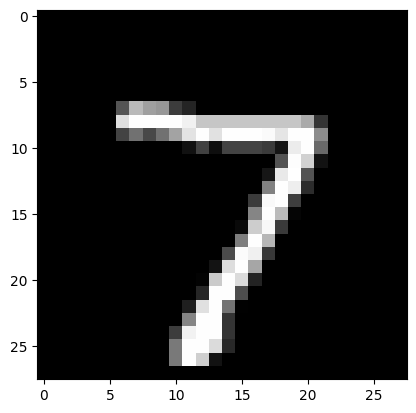

In [13]:
#image to show
plt.imshow(x_test[0], cmap='gray')
plt.show()